# From association to TMLE with the TWINS data

This notebook follows one question from an observed association to a targeted estimate. It uses
real twin births, so each step shows what a real data set supports and what it does not.
[Point-treatment TMLE](../technical-reference/point-treatment-tmle.md) gives the parameter, the influence curve, and the algorithm.

## The applied question

A perinatal epidemiologist asks how much first-year mortality would change if a child were born
below 2,500 g rather than at or above it. Twin pairs suit this question, because the two twins
share a mother, a pregnancy, and a birth date.

The target is **illustrative**, not a clinical claim. Low birth weight is a state that many
processes produce, not one well-defined treatment. A causal reading needs an intervention that sets
birth-weight status without other effects on mortality. The adjustment set also omits a strong
common cause, so the adjusted estimate is not a credible causal effect.

## What you will learn

| after this notebook you can | the section that shows it |
| --- | --- |
| encode real covariates without a variable that the birth itself determines | 2 |
| tell a crude association from a design stress test | 3 |
| write a protocol that records why its assumptions fail | 4 and 5 |
| compute g-computation, IPW, and TMLE by hand, and check the hand result against the package | 6 and 7 |
| read the assessment, the support report, and the sensitivity analysis | 8 and 9 |
| report a risk difference and a risk ratio with the correct interval scale | 10 |
| check a longitudinal estimator against an exact truth | 11 |

## Why this method

G-computation uses only the outcome model, and IPW uses only the treatment model. TMLE starts from
the outcome model and updates it with the treatment model, so the estimate uses both. Section 6
computes all three by hand on the same rows. The table defines the terms this notebook uses most.

| term | plain meaning | reference |
| --- | --- | --- |
| estimand | the number the question asks for, written before any model is chosen | [estimands](../user-guide/estimands.md) |
| nuisance | a model the estimate needs but the question does not ask about. Here, the outcome regression Q(A,W) and the treatment mechanism g(W) | [point-treatment TMLE](../technical-reference/point-treatment-tmle.md) |
| targeting | a small update to Q, weighted by g, that removes the first-order bias of the plug-in estimate | [targeting and bounds](../user-guide/methods-learners.md#targeting-and-bounds) |
| clever covariate | the weight that targeting gives each row's residual. For the ATE it is A/g(W) − (1−A)/(1−g(W)) | [counterfactual means and arm contrasts](../technical-reference/point-treatment-tmle.md#counterfactual-means-and-arm-contrasts) |
| influence curve | how much each row moves the estimate. Its variance gives the standard error | [inference](../technical-reference/inference.md) |
| cross-fitting | each row's nuisance prediction comes from models fit without that row | [CV-TMLE](../technical-reference/cv-tmle.md) |
| Super Learner | a learner that combines candidate learners with weights that cross-validation chooses | [learner choices](../user-guide/methods-learners.md#learner-choices) |
| positivity | every kind of child has some chance of each birth-weight state | [diagnostics](../user-guide/results-assessment.md#diagnostics) |
| double robustness | the point estimate stays consistent when either nuisance model is consistent | [point-treatment TMLE](../technical-reference/point-treatment-tmle.md) |
| sensitivity analysis | how strong an unmeasured confounder would need to be to change the conclusion | [sensitivity analysis](../user-guide/results-assessment.md#sensitivity-analysis) |

## 1. Setup and reproducibility

The data step downloads three CSV files from GitHub, so the notebook needs a network connection.
The three source URLs are pinned to one CEVAE commit. The code samples pairs rather than children,
so both twins stay together. The setup cell prints the installed `cleverly` version.

In [1]:
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import cleverly
from cleverly import (
    ATE,
    CausalStudy,
    CounterfactualMean,
    CrossFitting,
    Inference,
    LongitudinalTreatment,
    ModelSpec,
    PointTreatment,
    RegimeContrast,
    RiskRatio,
    Runtime,
    StudyProtocol,
    SuperLearner,
    TMLEMethod,
)
from cleverly.learners import thread_limit

SEED = 2026
N_PAIRS = 6_000
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
print("cleverly", cleverly.__version__)

cleverly 0.1.2


**What this output tells you.** The stored outputs in this notebook came from the version named
above. A different version can print different numbers. The setup sets no warning filter, so a
positivity or convergence warning from `cleverly` would appear under the cell that raised it. No
cell below shows one.

## 2. Load the pairs and encode the covariates

The [CEVAE TWINS README](https://github.com/AMLab-Amsterdam/CEVAE/blob/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS/ReadmeTwins) describes same-sex US twin pairs born in 1989–1991,
with twin 0 the lighter twin. Its source is the NBER linked birth and infant death files, so the
outcome is death in the first year of life. The "3years" in the file names means the three birth
years. The code therefore names the outcome `mortality_1y`.

TWINS is best known as the semi-synthetic benchmark of
[Louizos et al. (2017, arXiv v2, section 4.3)](https://arxiv.org/abs/1705.08821). That benchmark
keeps pairs in which both twins weigh under 2,000 g, treats being the heavier twin as treatment,
and hides one twin's outcome. This notebook samples 6,000 pairs from the whole file. It sets
treatment to birth weight below 2,500 g, so its numbers differ from that benchmark. The
[references](../references.md#the-twins-example) list the source.

The adjustment set is a small illustrative set of maternal background and pregnancy risk factors.
It holds no variable that the birth itself determines, such as birth order. In the
[covariate description](https://github.com/AMLab-Amsterdam/CEVAE/blob/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS/covar_desc.txt), `preterm` means a previous preterm or small
infant, not this pregnancy's gestation. The set omits gestational age (the gestat10 field), a strong common
cause of birth weight and mortality. The [covariate metadata](https://github.com/AMLab-Amsterdam/CEVAE/blob/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS/covar_type.txt) labels
maternal age, education, race, region, and year as categorical, so the code one-hot encodes them.
Binary missing values receive a fixed fill value plus one indicator per distinct missingness
pattern.

In [2]:
COMMIT = "9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd"
BASE_URL = f"https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/{COMMIT}/datasets/TWINS"
FILES = {
    "X": "twin_pairs_X_3years_samesex.csv",
    "T": "twin_pairs_T_3years_samesex.csv",
    "Y": "twin_pairs_Y_3years_samesex.csv",
}
raw = {name: pd.read_csv(f"{BASE_URL}/{filename}") for name, filename in FILES.items()}
assert raw["X"].shape[0] == raw["T"].shape[0] == raw["Y"].shape[0]

pair_rows = raw["X"].sample(n=N_PAIRS, random_state=SEED).index.sort_values().to_numpy()
X = raw["X"].loc[pair_rows].reset_index(drop=True)
T = raw["T"].loc[pair_rows].reset_index(drop=True)
Y = raw["Y"].loc[pair_rows].reset_index(drop=True)

shared = [
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "phyper",
    "preterm",
    "tobacco",
    "alcohol",
]
children = []
for twin in (0, 1):
    child = X[shared].copy()
    child["pair_id"] = np.arange(N_PAIRS)
    child["twin"] = twin
    child["birth_weight_g"] = T[f"dbirwt_{twin}"]
    child["mortality_1y"] = Y[f"mort_{twin}"].astype(int)
    children.append(child)

twins = (
    pd.concat(children, ignore_index=True).sort_values(["pair_id", "twin"]).reset_index(drop=True)
)
twins["low_birth_weight"] = (twins["birth_weight_g"] < 2_500).astype(int)

CATEGORICAL = ["mager8", "meduc6", "mrace", "mplbir_reg", "data_year"]
BINARY = ["dmar", "diabetes", "chyper", "phyper", "preterm", "tobacco", "alcohol"]
point_data = twins.copy()
adjustment = []
missing_patterns = set()
for column in BINARY:
    missing = point_data[column].isna()
    signature = missing.to_numpy().tobytes()
    if missing.any() and signature not in missing_patterns:
        indicator = f"{column}_missing"
        point_data[indicator] = missing.astype(float)
        adjustment.append(indicator)
        missing_patterns.add(signature)
    point_data[column] = point_data[column].fillna(0).astype(float)
    adjustment.append(column)

encoded = pd.get_dummies(
    point_data[CATEGORICAL].fillna(-1).astype("category"),
    prefix=CATEGORICAL,
    dtype=float,
)
point_data = pd.concat([point_data, encoded], axis=1)
adjustment.extend(encoded.columns.tolist())
ADJUSTMENT = tuple(adjustment)

print(f"children:                   {len(point_data):,}")
print(f"pairs:                      {point_data['pair_id'].nunique():,}")
print(f"encoded adjustment columns: {len(ADJUSTMENT)}")
print(f"low-birth-weight share:     {point_data['low_birth_weight'].mean():.4f}")
print(f"first-year mortality:       {point_data['mortality_1y'].mean():.4f}")

children:                   12,000
pairs:                      6,000
encoded adjustment columns: 47
low-birth-weight share:     0.5145
first-year mortality:       0.0359


**What this output tells you.** The sample holds 12,000 children in 6,000 pairs. The code builds
47 adjustment columns from 12 source fields. The low-birth-weight share is 0.5145, and the
first-year mortality is 0.0359. A rare outcome makes each arm's risk small, so section 10 reports
both the difference and the ratio.

## 3. Association first, then a design stress test

Let A indicate birth weight below 2,500 g and Y indicate death in the first year. The crude
difference E(Y | A=1) − E(Y | A=0) is descriptive.

Twins also offer a stress test. Within pairs where exactly one child falls below the threshold,
compare the two outcomes. This comparison controls factors that the pair shares. It targets only
those discordant pairs, and it keeps child-specific confounding. It is **not** a replacement ATE or
a causal truth.

In [3]:
observed_risks = point_data.groupby("low_birth_weight")["mortality_1y"].mean()
crude_rd = observed_risks.loc[1] - observed_risks.loc[0]

discordant_ids = (
    point_data.groupby("pair_id")["low_birth_weight"].nunique().loc[lambda value: value == 2].index
)
discordant = point_data[point_data["pair_id"].isin(discordant_ids)]
paired_outcomes = discordant.pivot(
    index="pair_id", columns="low_birth_weight", values="mortality_1y"
)
paired_differences = (paired_outcomes[1] - paired_outcomes[0]).to_numpy(float)
paired_rd = paired_differences.mean()
rng = np.random.default_rng(SEED)
paired_bootstrap = rng.choice(
    paired_differences, size=(20_000, len(paired_differences)), replace=True
).mean(axis=1)
paired_ci = np.quantile(paired_bootstrap, [0.025, 0.975])

assert len(paired_differences) == 1_290

association = pd.DataFrame(
    [
        {
            "contrast": "all children: crude association",
            "estimate": crude_rd,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "population": "sampled children",
        },
        {
            "contrast": "within threshold-discordant pairs",
            "estimate": paired_rd,
            "ci_low": paired_ci[0],
            "ci_high": paired_ci[1],
            "population": f"{len(paired_differences):,} discordant pairs",
        },
    ]
)
print(f"observed risk with A=0: {observed_risks.loc[0]:.4f}")
print(f"observed risk with A=1: {observed_risks.loc[1]:.4f}")
print()
print(association.round(4).to_string(index=False))

observed risk with A=0: 0.0043
observed risk with A=1: 0.0658



                         contrast  estimate  ci_low  ci_high             population
  all children: crude association    0.0615     NaN      NaN       sampled children
within threshold-discordant pairs    0.0085  0.0008   0.0171 1,290 discordant pairs


**What this output tells you.** The observed risk is 0.0658 for children below 2,500 g and 0.0043
for the others. The crude difference is 0.0615. Within the 1,290 threshold-discordant pairs, the
difference is 0.0085, with a paired bootstrap interval of [0.0008, 0.0171].

The two estimates target different populations and weight ranges, so the gap alone does not
measure confounding. Section 7 compares estimators of one target. This comparison changes the
target, so its gap and the spread in section 7 are not on one scale.

## 4. Write the protocol

A `StudyProtocol` records the scientific design before any model runs. It names the population,
time zero, the strategies, the outcome, and the reason each identification assumption holds or
fails. Every result fitted from the study stores its fingerprint. This design shares no field with
the [navigation program](index.md#the-shared-study-design), so the code writes a new protocol
rather than starting from `navigation_protocol()`.

In [4]:
protocol = StudyProtocol(
    target_population="Children from same-sex US twin births in 1989-1991",
    eligibility=("Both twins have a recorded birth weight and first-year outcome",),
    time_zero="Birth, when birth weight is measured and first-year follow-up begins",
    treatment_strategies=(
        "Set birth weight below 2,500 g",
        "Set birth weight at or above 2,500 g",
    ),
    treatment_versions=(
        "No well-defined intervention version; this is an illustrative threshold state",
        "No well-defined intervention version; this is an illustrative threshold state",
    ),
    outcome="Death from any cause in the first year of life",
    horizon="First year after birth",
    intercurrent_event_handling=("Count every recorded first-year death",),
    interference_unit="Twin pair",
    assumption_rationale=(
        "The adjustment set omits gestational age, so exchangeability is not credible",
        "Birth-weight categories do not define intervention versions, so consistency is "
        "not credible",
        "Pair clustering addresses dependence but does not remove interference",
    ),
)
print("\n".join(protocol.summary_lines()))

causal study protocol: schema 1; 0643c45a6ab43754
target population: Children from same-sex US twin births in 1989-1991
eligibility: ['Both twins have a recorded birth weight and first-year outcome']
time zero: Birth, when birth weight is measured and first-year follow-up begins
treatment strategies: ['Set birth weight below 2,500 g', 'Set birth weight at or above 2,500 g']
treatment versions: ['No well-defined intervention version; this is an illustrative threshold state', 'No well-defined intervention version; this is an illustrative threshold state']
outcome: Death from any cause in the first year of life
horizon: First year after birth
intercurrent-event handling: ['Count every recorded first-year death']
interference unit: Twin pair
assumption rationale: ['The adjustment set omits gestational age, so exchangeability is not credible', 'Birth-weight categories do not define intervention versions, so consistency is not credible', 'Pair clustering addresses dependence but does not rem

**What this output tells you.** The first line gives the schema version and the fingerprint
`0643c45a6ab43754`. The other lines fix the population, time zero, the two strategies, and the
outcome before any model runs.

| protocol line | what it records for this study |
| --- | --- |
| time zero | birth, when birth weight is measured and follow-up starts |
| treatment versions | no well-defined intervention sets a birth weight |
| interference unit | the twin pair, because one twin's growth can affect the other's survival |
| assumption rationale | exchangeability and consistency are not credible, and pair clustering does not remove interference |

The protocol states its own failures. A reader can therefore tell that each estimate below
demonstrates a method and is not a causal finding.

## 5. State the causal target before fitting

The illustrative target is the population ATE, E(Y¹) − E(Y⁰). The g-formula identifies it under
consistency, conditional exchangeability given the encoded adjustment set, positivity, and no
interference. No interference is doubtful here, because co-twins share a uterus and one twin's
growth can affect the other's survival. Pair clustering changes folds and uncertainty. It does not
remove confounding or interference.

In [5]:
point_study = CausalStudy(
    point_data,
    design=PointTreatment(
        outcome="mortality_1y",
        treatment="low_birth_weight",
        adjustment=ADJUSTMENT,
        cluster="pair_id",
        outcome_family="binomial",
    ),
    protocol=protocol,
)
ate_effect = point_study.identify(ATE(reference=0))
print(ate_effect.summary())

average treatment effect, E[Y^a] - E[Y^reference]
identified by explicit-adjustment: E_W[E(mortality_1y | low_birth_weight=a, W)] - E_W[E(mortality_1y | low_birth_weight=0, W)] for a in [1]
adjustment/history: ['dmar', 'diabetes_missing', 'diabetes', 'chyper', 'phyper', 'preterm_missing', 'preterm', 'tobacco_missing', 'tobacco', 'alcohol_missing', 'alcohol', 'mager8_1', 'mager8_2', 'mager8_3', 'mager8_4', 'mager8_5', 'mager8_6', 'mager8_7', 'mager8_8', 'meduc6_-1.0', 'meduc6_1.0', 'meduc6_2.0', 'meduc6_3.0', 'meduc6_4.0', 'meduc6_5.0', 'mrace_1', 'mrace_2', 'mrace_3', 'mrace_4', 'mrace_5', 'mrace_6', 'mrace_7', 'mrace_8', 'mrace_9', 'mplbir_reg_-1.0', 'mplbir_reg_0.0', 'mplbir_reg_1.0', 'mplbir_reg_2.0', 'mplbir_reg_3.0', 'mplbir_reg_4.0', 'mplbir_reg_5.0', 'mplbir_reg_6.0', 'mplbir_reg_7.0', 'mplbir_reg_8.0', 'data_year_89', 'data_year_90', 'data_year_91']
required nuisances: ['outcome_regression', 'treatment_mechanism']
assumptions:
  - consistency: Y = Y^a when A = a
  - no interfer

**What this output tells you.** The first line names the estimand: the ATE, with 0 as the reference
level. The second line is the g-formula that identifies it from observed data. The adjustment list
shows the 47 encoded columns, with the missingness indicators beside their fields. The fit needs
two nuisance models: the outcome regression and the treatment mechanism.

The four assumptions are the library's generic list. The protocol lines below them record why this
design does not support two of them. Every result from this study carries the fingerprint
`0643c45a6ab43754`.

## 6. The estimator ladder

- G-computation fits Q(A,W), predicts each row with A set to 1 and to 0, and averages the
  difference.
- IPW fits g(W) = P(A=1 | W) and weights each observed outcome by 1/g or 1/(1−g).
- TMLE starts from Q. It then makes one small update to Q, weighted by g, so that the estimate's
  first-order bias term averages to zero. [Point-treatment TMLE](../technical-reference/point-treatment-tmle.md#counterfactual-means-and-arm-contrasts)
  gives the influence function that this update solves.

The three hand calculations are point estimates. The package fits in section 7 add cluster-robust
intervals. The code asserts two witnesses. The counterfactual update must reproduce the
observed-row update, and the score before targeting must be nonzero.

In [6]:
def scaled_logistic():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3_000, random_state=SEED))


def expit(value):
    return 1.0 / (1.0 + np.exp(-value))


def logit(probability):
    clipped = np.clip(probability, 1e-12, 1 - 1e-12)
    return np.log(clipped / (1 - clipped))


W = point_data.loc[:, ADJUSTMENT]
A = point_data["low_birth_weight"].to_numpy()
outcome = point_data["mortality_1y"].to_numpy()
design_all = pd.concat([point_data[["low_birth_weight"]], W], axis=1)

with thread_limit():
    q_model = scaled_logistic().fit(design_all, outcome)
q_obs = q_model.predict_proba(design_all)[:, 1]
q1 = q_model.predict_proba(design_all.assign(low_birth_weight=1))[:, 1]
q0 = q_model.predict_proba(design_all.assign(low_birth_weight=0))[:, 1]
gcomp_ate = q1.mean() - q0.mean()

with thread_limit():
    g_model = scaled_logistic().fit(W, A)
g1 = np.clip(g_model.predict_proba(W)[:, 1], 0.01, 0.99)
ipw_ate = np.mean(A * outcome / g1) - np.mean((1 - A) * outcome / (1 - g1))

H = A / g1 - (1 - A) / (1 - g1)
initial_score = np.mean(H * (outcome - q_obs))
epsilon = 0.0
for _ in range(50):
    q_star_obs = expit(logit(q_obs) + epsilon * H)
    step = np.mean(H * (outcome - q_star_obs)) / np.mean(H**2 * q_star_obs * (1 - q_star_obs))
    epsilon += step
    if abs(step) < 1e-12:
        break

q_star_obs = expit(logit(q_obs) + epsilon * H)
q1_star = expit(logit(q1) + epsilon / g1)
q0_star = expit(logit(q0) - epsilon / (1 - g1))
manual_tmle_ate = q1_star.mean() - q0_star.mean()
final_score = np.mean(H * (outcome - q_star_obs))

# The counterfactual update must reproduce the observed-row update that epsilon solved.
assert np.allclose(q_star_obs, np.where(A == 1, q1_star, q0_star), rtol=0, atol=1e-12)
# Nonzero witnesses: targeting had a score to remove, and it moved the estimate.
assert abs(initial_score) > 1e-5 and abs(epsilon) > 0
assert abs(final_score) < 1e-10

ladder = pd.DataFrame(
    {
        "quantity": [
            "crude association",
            "g-computation ATE",
            "IPW ATE (1% truncation)",
            "hand-built TMLE ATE",
            "fluctuation epsilon",
            "residual score before targeting",
            "residual score after targeting",
        ],
        "value": [
            crude_rd,
            gcomp_ate,
            ipw_ate,
            manual_tmle_ate,
            epsilon,
            initial_score,
            final_score,
        ],
    }
)
print(ladder.to_string(index=False))

                       quantity  value
              crude association 0.0615
              g-computation ATE 0.0565
        IPW ATE (1% truncation) 0.0571
            hand-built TMLE ATE 0.0570
            fluctuation epsilon 0.0042
residual score before targeting 0.0005
 residual score after targeting 0.0000

**What this output tells you.** Section 7 rounds the three estimates. G-computation gives 0.0565,
IPW gives 0.0571, and the hand-built TMLE gives 0.0570. Before targeting, the residual score is
5.0875e-04. After targeting it is 2.9606e-19, which is zero to machine precision. The fluctuation
epsilon is 4.2286e-03, so the update did move Q.

Targeting removes the initial score, so a small score gives a small move. Section 7 prints the move
from g-computation to TMLE as 5.114e-04, close to the initial score.

This is a numerical property of the fitted targeting step. It does not prove identification, model
correctness, or interval coverage. Those also need nuisance convergence, support, and valid
dependence handling. The movement toward IPW is not evidence of double robustness, which is a
repeated-sampling property.

## 7. The package estimators

The ordinary package fit uses the same rows and nuisance learners as the hand calculation. It
bounds the propensity at the package default rather than at 0.01. The hand calculation targets the
ATE with one clever covariate. The package targets both arm means, then takes their contrast. The
code prints the gap between the two and asserts that it is below a tenth of the targeting move.

The main analysis adds cross-fitting and a small Super Learner for both nuisance functions. Inner
cross-validation weights logistic regression and gradient boosting. Both package fits use
influence-curve inference clustered by twin pair, as [clusters](../technical-reference/inference.md#clusters)
describes.

In [7]:
parametric_models = ModelSpec(
    outcome_learner=scaled_logistic(), treatment_learner=scaled_logistic()
)
point_inference = Inference(alpha=0.05, simultaneous=False)
runtime = Runtime(random_state=SEED, n_jobs=1)
ordinary_method = TMLEMethod(
    models=parametric_models,
    cross_fitting=CrossFitting(enabled=False),
    inference=point_inference,
    runtime=runtime,
)
ordinary_result = ate_effect.estimate(method=ordinary_method)
ordinary_estimate = ordinary_result["ate"]
package_gap = ordinary_estimate.psi - manual_tmle_ate
targeting_shift = manual_tmle_ate - gcomp_ate
print(f"ordinary package TMLE minus hand-built TMLE: {package_gap:.3e}")
print(f"hand-built TMLE minus g-computation:         {targeting_shift:.3e}")
assert abs(package_gap) < 0.1 * abs(targeting_shift)
assert np.isfinite([ordinary_estimate.std_error, *ordinary_estimate.ci]).all()


def classifier_super_learner():
    return SuperLearner(
        library=[
            ("logistic", scaled_logistic()),
            (
                "boosting",
                HistGradientBoostingClassifier(
                    max_iter=100, min_samples_leaf=30, random_state=SEED
                ),
            ),
        ],
        task="classification",
        n_folds=3,
        random_state=SEED,
        n_jobs=1,
    )


flexible_method = TMLEMethod(
    models=ModelSpec(
        outcome_learner=classifier_super_learner(),
        treatment_learner=classifier_super_learner(),
    ),
    cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
    inference=point_inference,
    runtime=runtime,
)
flexible_result = ate_effect.estimate(method=flexible_method)
print()
print(flexible_result.summary())

ordinary package TMLE minus hand-built TMLE: -1.130e-06
hand-built TMLE minus g-computation:         5.114e-04



Targeted maximum likelihood estimation
n = 12000; covariates = 47; P(A=1) = 0.5145
causal estimand: average treatment effect, E[Y^a] - E[Y^reference]
identification: explicit-adjustment; E_W[E(mortality_1y | low_birth_weight=a, W)] - E_W[E(mortality_1y | low_birth_weight=0, W)] for a in [1]
required nuisances: outcome_regression, treatment_mechanism
identification assumptions: consistency: Y = Y^a when A = a; no interference: one unit's potential outcome does not depend on other units' treatment assignments; no unmeasured confounding: Y^a is independent of A given W; positivity: P(low_birth_weight = a | W) > 0 almost surely for every supported treatment level a in [0, 1]
causal study protocol: schema 1; 0643c45a6ab43754
target population: Children from same-sex US twin births in 1989-1991
eligibility: ['Both twins have a recorded birth weight and first-year outcome']
time zero: Birth, when birth weight is measured and first-year follow-up begins
treatment strategies: ['Set birth weigh

**What this output tells you.** The first two lines compare the fits. The ordinary package TMLE
differs from the hand-built TMLE by -1.130e-06. The targeting move is 5.114e-04, so the two
constructions agree well within that move.

The summary then repeats the estimand and the protocol from sections 4 and 5. Skip those lines,
and read the lines below them.

| summary line | value | what it means |
| --- | --- | --- |
| `clusters = 6000 (cluster-robust variance)` | one cluster per twin pair | the standard error treats the pair, not the child, as the independent unit |
| `stacked CV-TMLE (Levy)` | 3 folds | each nuisance prediction comes from models fit on the other two folds |
| `propensity truncated to` | [0.004859, 0.9951] | the default bound 5/(√n log n) at n = 12000 |
| the `ate` row | 0.057766, with a 95% interval of [0.049919, 0.065614] | the main estimate of the illustrative ATE |

                  method  estimate  ci_low  ci_high
       crude association    0.0615     NaN      NaN
           g-computation    0.0565     NaN      NaN
                     IPW    0.0571     NaN      NaN
         hand-built TMLE    0.0570     NaN      NaN
   ordinary package TMLE    0.0570  0.0493   0.0647
   Super Learner CV-TMLE    0.0578  0.0499   0.0656
within-pair stress test*    0.0085  0.0008   0.0171


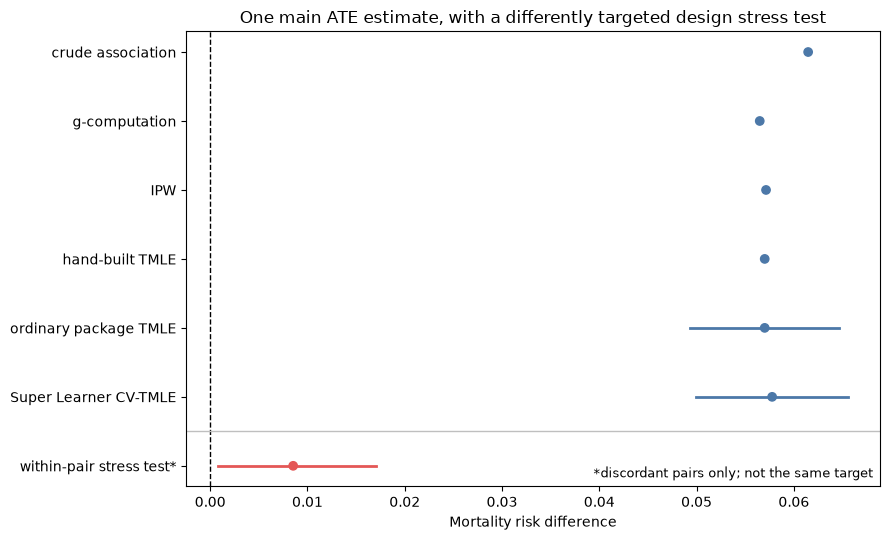

In [8]:
main_estimate = flexible_result["ate"]
comparison = pd.DataFrame(
    [
        {"method": "crude association", "estimate": crude_rd},
        {"method": "g-computation", "estimate": gcomp_ate},
        {"method": "IPW", "estimate": ipw_ate},
        {"method": "hand-built TMLE", "estimate": manual_tmle_ate},
        {
            "method": "ordinary package TMLE",
            "estimate": ordinary_estimate.psi,
            "ci_low": ordinary_estimate.ci[0],
            "ci_high": ordinary_estimate.ci[1],
        },
        {
            "method": "Super Learner CV-TMLE",
            "estimate": main_estimate.psi,
            "ci_low": main_estimate.ci[0],
            "ci_high": main_estimate.ci[1],
        },
        {
            "method": "within-pair stress test*",
            "estimate": paired_rd,
            "ci_low": paired_ci[0],
            "ci_high": paired_ci[1],
        },
    ]
)
assert (
    comparison.loc[comparison["method"] == "ordinary package TMLE", ["ci_low", "ci_high"]]
    .notna()
    .all(axis=None)
)

stress = comparison["method"].str.endswith("*").to_numpy()
colors = np.where(stress, "#e45756", "#4c78a8")
fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(comparison))
ax.scatter(comparison["estimate"], y, color=colors, zorder=3)
for index, row in comparison.dropna(subset=["ci_low"]).iterrows():
    ax.plot([row.ci_low, row.ci_high], [index, index], color=colors[index], linewidth=2)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.axhline(stress.argmax() - 0.5, color="0.75", linewidth=1)
ax.set_yticks(y, comparison["method"])
ax.set_xlabel("Mortality risk difference")
ax.set_title("One main ATE estimate, with a differently targeted design stress test")
ax.text(
    0.99,
    0.02,
    "*discordant pairs only; not the same target",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
)
ax.invert_yaxis()
fig.tight_layout()
print(comparison.round(4).to_string(index=False))

**What this output tells you.** The table and the figure put every estimate on one risk-difference
scale. The hand-built TMLE and the ordinary package TMLE both round to 0.0570. Only the package fits
report an interval, from their cluster-robust influence-curve variance. The Super Learner CV-TMLE
gives 0.0578, with an interval of [0.0499, 0.0656]. The within-pair stress test is 0.0085, and the
figure marks it with a star because it has another target.

The Super Learner CV-TMLE is the main analysis. Its interval still needs adequate nuisance rates,
support, and dependence handling. The nearby estimates show numerical stability under one
adjustment set. They do not validate exchangeability or show that any estimator is correct.
Overlapping intervals do not test estimator equivalence, because these estimates share one sample.

## 8. Diagnose the observable parts of the fit

`result.assess()` runs validation, diagnostics, and sensitivity in one report, as
[run the assessment battery](../user-guide/results-assessment.md#run-the-assessment-battery)
describes. The call passes the omitted-confounding strengths that section 9 reads. The code prints
the assessment summary, then the nuisance and score-equation reports. The assessment cannot detect
an ill-defined intervention, a missing common cause, or a wrong causal graph.

In [9]:
assessment = flexible_result.assess(
    random_state=SEED,
    arguments={
        "omitted_confounding": {"estimand": "ate", "cf_y": 0.05, "cf_d": 0.05, "rho": 1.0},
    },
)
print(assessment.summary())
print("needs attention:", tuple(item.name for item in assessment.attention))
print()
print(assessment.report("nuisance_models").summary())
print()
print(assessment.report("score_equations").summary())

Returned results
----------------
surface      operation            result                                                                                                                                                                                     
-----------  -------------------  -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
validation   support              maximum truncated fraction 0.0%; minimum effective-sample-size ratio 91.3%; group load: mean:h0 5321.8/12000 Kish-equivalent mask rows (44.3%; 44.3% all; draw 01 of 01); not estimator ESS
sensitivity  omitted_confounding  cf_y=0.05, cf_d=0.05, rho=1; bias-adjusted interval [0.03844, 0.07709]                                                                                                                     
sensitivity  robustness_value     point robustness value 0.142; confidence-lim

**What this output tells you.** Read the parts in order.

| output part | what it shows |
| --- | --- |
| `Returned results` | the rows that report numbers without a verdict: support and five sensitivity rows |
| `Checks` and `needs attention` | `score_equations` passed. `nuisance_models` is a warning, and it is the one row that needs attention |
| `Not run` | `benchmark`, `refute`, and `truncation_curve` are deferred, because they refit or retarget. `simulated_confounding` is unavailable for a clustered fit |
| nuisance model diagnostics | a propensity AUC of 0.6076 and an outcome calibration slope of 0.6901 |
| score-equation check | targeting solved the estimated efficient score equation |

The propensity AUC is a prediction metric, not a positivity test. A low AUC does not certify
overlap in the tails, and a high AUC does not prove a violation.

A calibration slope below 1 means the out-of-fold risk predictions are more extreme than the
observed risks. The outcome slope of 0.6901 is below the lower edge of the fixed band that the
flag applies, so the verdict line flags the outcome model. The report does not print that band. The
[nuisance diagnostics source](https://github.com/esbraun/cleverly-tmle/blob/main/src/cleverly/validation/nuisance.py)
holds the rule.

Read the flag as a prompt to review the outcome model. It is not a finding that the estimate is
wrong. The roadmap item [RM15](../roadmap.md#rm15-calibration-slope-warning-rule) records that the
band also flags correctly specified models when the signal is weak. It also records that the
flag's phrase about biased weights is not something the rule measures.

Positivity / overlap diagnostics
--------------------------------
n = 12000; propensity truncated to [0.004859, 0.9951]

g(W) quantile  0%      1%      5%      25%     50%     75%     95%     99%     100%  
-------------  ------  ------  ------  ------  ------  ------  ------  ------  ------
overall        0.2384  0.3257  0.3685  0.4255  0.4886  0.5947  0.7341  0.8073  0.9389
treated        0.2687  0.3341  0.3715  0.4346  0.5159  0.6254  0.7586  0.8238  0.9389
control        0.2384  0.3245  0.3658  0.4163  0.4652  0.5548  0.6997  0.7784  0.9220

arm      n     effective n  ESS / n  top 1% weight  top 5% weight
-------  ----  -----------  -------  -------------  -------------
treated  6174  5881.8       0.953    0.016          0.074        
control  5826  5321.8       0.913    0.027          0.099        

threshold  P(g < t)  P(g > 1-t)
---------  --------  ----------
0.01       0.0000    0.0000    
0.025      0.0000    0.0000    
0.05       0.0000    0.0000    
0.1        0.0000    0.

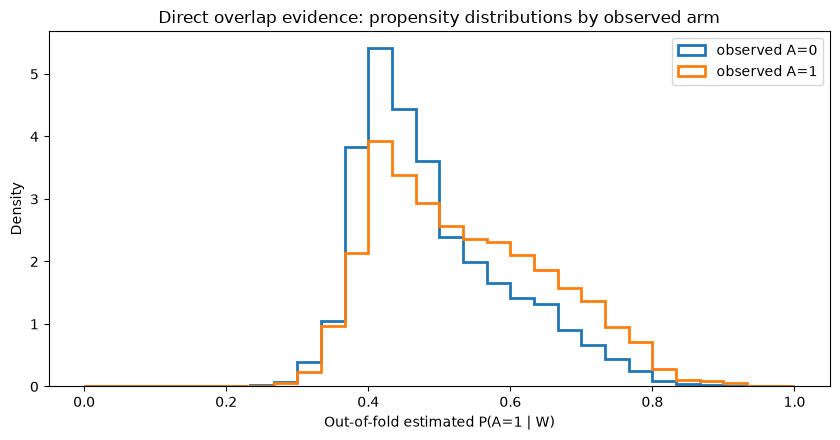

In [10]:
positivity = assessment.report("support")
g_hat = flexible_result.nuisance.propensity.arm(1.0)
print(positivity.summary())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bins = np.linspace(0, 1, 31)
ax.hist(g_hat[A == 0], bins=bins, density=True, histtype="step", linewidth=2, label="observed A=0")
ax.hist(g_hat[A == 1], bins=bins, density=True, histtype="step", linewidth=2, label="observed A=1")
ax.set_xlabel("Out-of-fold estimated P(A=1 | W)")
ax.set_ylabel("Density")
ax.set_title("Direct overlap evidence: propensity distributions by observed arm")
ax.legend()
fig.tight_layout()

**What this output tells you.** The fitted propensities run from 0.2384 to 0.9389. No estimate
reaches either fitted truncation bound, 0.004859 or 0.9951. The 0.1 threshold row reports
`P(g > 1−t) = 0.0012`, so 0.12% of estimates exceed 0.9. The 0.05 row reports no estimate
outside [0.05, 0.95]. The truncation line still reads
`truncated: 0 unit(s) (0.00%)`.

The ESS ratio is 0.953 for the treated arm and 0.913 for the control arm. The histogram shows the
two arms' propensity distributions over the same range.

The support row in section 8 is under `Returned results`, not under `Checks`. The library makes it
a warning only for a truncation breach or an intervention with zero estimated support. It applies
no effective-sample-size cutoff, because none is derived.

The maximum clever covariate is 12.82, which is 1/(1 − 0.9220) for the largest control propensity.
It does not bound total influence, which also contains the outcome residual and the plug-in term.
[Positivity and overlap](../technical-reference/validation-methods.md#positivity-and-overlap)
defines each column.

## 9. Put omitted-confounding sensitivity on a concrete scale

The omitted-variable bound of Chernozhukov, Cinelli, Newey, Sharma and Syrgkanis (2026) limits the
bias that an unmeasured confounder can add. Its strength cf_y is the share of the residual outcome
variation that the confounder explains. Its strength cf_d is the share of the residual treatment
variation. The E-value of VanderWeele and Ding (2017) asks the same question on the risk-ratio
scale. The [references](../references.md#sensitivity-analysis) list both sources, and
[omitted-variable bounds](../technical-reference/validation-methods.md#omitted-variable-bounds-robustness-value-benchmark-and-contours) defines each quantity.

The analysis is a scenario analysis, not a detector. The code reads the bounds at cf_y = cf_d =
0.05 and the worst-case alignment ρ = 1 from the assessment. It then calibrates the strength scale
against two observed covariates, `preterm` and `tobacco`. The benchmark refits without them. The
code calls it directly, because `assess(include_refits=True)` would also run the refutations.

In [11]:
omitted = assessment.report("omitted_confounding")
benchmark = flexible_result.sensitivity.benchmark(
    covariates=("preterm", "tobacco"), estimand="ate", random_state=SEED
)
print(omitted.summary())
print()
print(benchmark.summary())

Omitted-variable sensitivity for 'ate'
--------------------------------------------
estimate 0.057766; maximal bias sqrt(sigma^2 nu^2) = 0.37673
assumed confounding: cf_y = 0.05, cf_d = 0.05, rho = 1 -> bias <= 0.019326
bias-adjusted bounds:  [0.038441, 0.077092]
with 95% one-sided CIs: [0.03256, 0.084421] (the sign of the effect survives)

robustness value RV   = 0.1420: a confounder explaining 14.2% of the residual variation in BOTH the outcome and treatment would move the estimate to 0.
robustness value RVa  = 0.1311: the same, for the 95% confidence bound.

Benchmark for 'ate' against ['preterm', 'tobacco']
------------------------------------------------
quantity  with covariates  without 
--------  ---------------  --------
estimate  0.057766         0.057777
sigma^2   0.034128         0.034129
nu^2      4.1586           4.1015  

implied cf_y = 0.0000, cf_d = 0.0139, rho = 0.0504
the estimate moved by +1.0669e-05 when these covariates were dropped


**What this output tells you.** At cf_y = cf_d = 0.05 and ρ = 1, the bias bound is 0.019326. The
bias-adjusted bounds are [0.038441, 0.077092], and the one-sided 95% limits are [0.03256, 0.084421].
The output states that the sign of the effect survives. The robustness value is 0.1420. It assumes
cf_y = cf_d and worst-case alignment. The value is a threshold, not the probability that
confounding exists.

Interpret this ordinary-TMLE value only if the fitted assignment model consistently estimates the
full assignment mechanism given the declared adjustment set. This seeded fit cannot establish that
condition.

The benchmark drops `preterm` and `tobacco`, and the estimate moves from 0.057766 to 0.057777. The
implied strengths are cf_y = 0 and cf_d = 0.0139, so the chosen cf_d of 0.05 is about four times
the benchmark. The implied cf_y rounds to 0 because σ² barely rose when the covariates were dropped.
It is 0.034128 with them and 0.034129 without them. The benchmark therefore gives no scale for cf_y,
and the chosen cf_y = 0.05 is an assumption. It also does not show that an omitted variable
resembles those covariates.

The assessment's `evalue` row gives 26.94 for the point risk ratio and 17.33 for its confidence
limit. If its treatment and outcome associations had equal strength, each would need the
reported value to explain the ratio away. Unequal strengths can trade off. These values
do not make strong unmeasured confounding unlikely, because
the adjustment set omits gestational age.

The within-pair gap in section 3 is consistent with confounding, with effects that differ across
the weight range, or with both. [Almond, Chay and Lee (2005)](https://www.nber.org/papers/w10552)
discuss both readings, and the [references](../references.md#the-twins-example) give the published
version.

## 10. Report absolute and relative scales without mixing uncertainty scales

A risk difference and a risk ratio answer different reporting questions. The code estimates both
with the same CV-TMLE configuration. The typed `RiskRatio` fit builds its influence-curve interval
on the log scale and reports the exponentiated limits, as
[transformed parameters](../technical-reference/inference.md#transformed-parameters) describes.

In [12]:
risk_result = point_study.estimate(CounterfactualMean(), method=flexible_method)
ratio_result = point_study.estimate(RiskRatio(reference=0), method=flexible_method)
risk0 = risk_result["ey[0]"]
risk1 = risk_result["ey[1]"]
ratio = ratio_result["rr"]
scale_table = pd.DataFrame(
    [
        {
            "quantity": "risk under A=0",
            "estimate": risk0.psi,
            "ci_low": risk0.ci[0],
            "ci_high": risk0.ci[1],
            "uncertainty": "risk scale",
        },
        {
            "quantity": "risk under A=1",
            "estimate": risk1.psi,
            "ci_low": risk1.ci[0],
            "ci_high": risk1.ci[1],
            "uncertainty": "risk scale",
        },
        {
            "quantity": "risk difference",
            "estimate": main_estimate.psi,
            "ci_low": main_estimate.ci[0],
            "ci_high": main_estimate.ci[1],
            "uncertainty": "difference scale",
        },
        {
            "quantity": "risk ratio",
            "estimate": ratio.psi,
            "ci_low": ratio.ci[0],
            "ci_high": ratio.ci[1],
            "uncertainty": "ratio scale from log-scale inference",
        },
    ]
)
upper_half_width = np.log(ratio.ci[1]) - np.log(ratio.psi)
lower_half_width = np.log(ratio.psi) - np.log(ratio.ci[0])
print(scale_table.round(4).to_string(index=False))
print()
print(f"log-scale distance from the ratio to its upper limit: {upper_half_width:.4f}")
print(f"log-scale distance from the ratio to its lower limit: {lower_half_width:.4f}")

       quantity  estimate  ci_low  ci_high                          uncertainty
 risk under A=0    0.0045  0.0027   0.0064                           risk scale
 risk under A=1    0.0623  0.0547   0.0699                           risk scale
risk difference    0.0578  0.0499   0.0656                     difference scale
     risk ratio   13.7223  8.9200  21.1098 ratio scale from log-scale inference

log-scale distance from the ratio to its upper limit: 0.4307
log-scale distance from the ratio to its lower limit: 0.4307


**What this output tells you.** The risk is 0.0045 under A=0 and 0.0623 under A=1. The difference
is 0.0578, and the ratio is 13.7223. The ratio is large because the reference risk is small. The
ratio interval [8.9200, 21.1098] is not symmetric around 13.7223 on the ratio scale. The last two
lines show a log-scale distance of 0.4307 on each side, so the interval is symmetric on the log
scale. Report both scales, and name the scale of each interval.

## 11. A semi-synthetic longitudinal extension with known truth

The source prenatal fields are end-of-pregnancy summaries, and their metadata do not establish a
sequence of measurements. This section therefore keeps one real baseline row per sampled pair. It
generates longitudinal nodes with the `sim_` prefix and a synthetic outcome. Nothing below is a
finding about prenatal care or mortality.

W1 is the marital-status field. W2 is 1 when the mother has diabetes or chronic hypertension. The
code writes each later node from this table.

| node | depends on |
| --- | --- |
| A1 | W1, W2 |
| L2 | A1, W2 |
| A2 | A1, L2, W1 |
| Y | A1, A2, L2, W2 |

L2 depends on A1 and affects both A2 and Y, so it is a time-varying confounder for the second
treatment. Every conditional law is written down, so the code computes the always-versus-never
truth exactly over the empirical baseline population. [Longitudinal TMLE](../technical-reference/longitudinal-tmle.md)
gives the estimator.

In [13]:
sim_w1 = X["dmar"].fillna(0).to_numpy(float)
sim_w2 = np.maximum(
    X["diabetes"].fillna(0).to_numpy(float),
    X["chyper"].fillna(0).to_numpy(float),
)
sim_rng = np.random.default_rng(SEED + 1)

sim_p_a1 = expit(-0.2 + 0.8 * sim_w1 - 0.6 * sim_w2)
sim_a1 = sim_rng.binomial(1, sim_p_a1)
sim_p_l2 = expit(-0.7 + 0.9 * sim_a1 + 0.8 * sim_w2)
sim_l2 = sim_rng.binomial(1, sim_p_l2)
sim_p_a2 = expit(-0.3 + 0.5 * sim_a1 + sim_l2 + 0.4 * sim_w1)
sim_a2 = sim_rng.binomial(1, sim_p_a2)
sim_p_y = expit(-2.2 - 0.35 * sim_a1 - 0.55 * sim_a2 + 0.9 * sim_l2 + 0.5 * sim_w2)
sim_y = sim_rng.binomial(1, sim_p_y)

semi = pd.DataFrame(
    {
        "sim_W1": sim_w1,
        "sim_W2": sim_w2,
        "sim_A1": sim_a1,
        "sim_L2": sim_l2,
        "sim_A2": sim_a2,
        "sim_Y": sim_y,
    }
)


def exact_regime_risk(a1, a2):
    p_l2 = expit(-0.7 + 0.9 * a1 + 0.8 * sim_w2)
    q_l2_0 = expit(-2.2 - 0.35 * a1 - 0.55 * a2 + 0.5 * sim_w2)
    q_l2_1 = expit(-2.2 - 0.35 * a1 - 0.55 * a2 + 0.9 + 0.5 * sim_w2)
    return np.mean((1 - p_l2) * q_l2_0 + p_l2 * q_l2_1)


truth_always = exact_regime_risk(1, 1)
truth_never = exact_regime_risk(0, 0)
truth_contrast = truth_always - truth_never
assert np.isclose(truth_contrast, -0.06464265455218184)

print(f"P(sim_A1=1):                    {semi['sim_A1'].mean():.4f}")
print(f"P(sim_L2=1):                    {semi['sim_L2'].mean():.4f}")
print(f"P(sim_A2=1):                    {semi['sim_A2'].mean():.4f}")
print(f"P(sim_Y=1):                     {semi['sim_Y'].mean():.4f}")
print(f"exact risk: always              {truth_always:.4f}")
print(f"exact risk: never               {truth_never:.4f}")
print(f"exact always-minus-never truth: {truth_contrast:.4f}")

P(sim_A1=1):                    0.5920
P(sim_L2=1):                    0.4685
P(sim_A2=1):                    0.6643
P(sim_Y=1):                     0.0955
exact risk: always              0.0759
exact risk: never               0.1405
exact always-minus-never truth: -0.0646


**What this output tells you.** The first four lines give the observed share of each node. The
shares run from 0.0955 for the outcome to 0.6643 for the second treatment, so no node is constant. The written laws
give an exact risk of 0.0759 under always treat and 0.1405 under never treat. The truth is
therefore −0.0646. These three values come from the laws, not from a fit.

Longitudinal TMLE (2 time points, n = 6000)

parameter                     estimate  std. error  95% CI              p-value
----------------------------  --------  ----------  ------------------  -------
ate_regimen[always vs never]  -0.0641   0.0128      [-0.0892, -0.0390]  <1e-4  

  time points: 2
  outcome family: binomial
  regimens: always=(1/1), never=(0/0)
  reference: never
  cross-fitting: 3 fold(s)
  g_bounds: fixed [0.01, 1] on each cumulative treatment-and-censoring probability (package default; R ltmle-compatible heuristic -- inspect truncation diagnostics)
  confidence level: 95%
  random_state: 2026
  causal estimand: contrast of each regime against the reference
  identification: explicit-adjustment; sequential g-formula under the declared treatment regimen
  required nuisances: sequential_outcome_regressions, treatment_and_censoring_mechanisms
  identification assumptions: consistency: each observed history equals the potential history under its realized regimen; no 

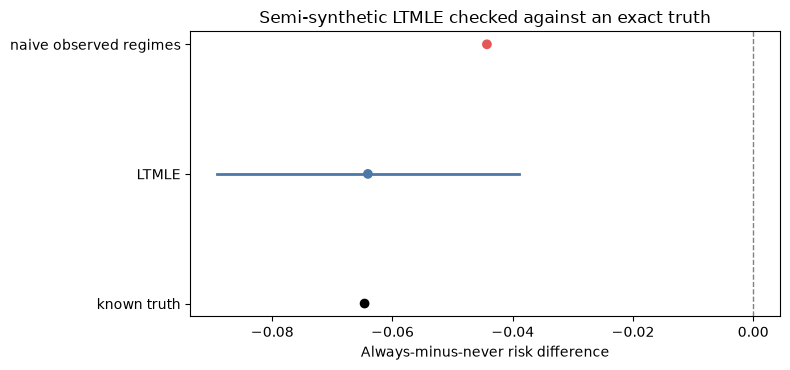

In [14]:
long_study = CausalStudy(
    semi,
    design=LongitudinalTreatment(
        outcome="sim_Y",
        treatment=("sim_A1", "sim_A2"),
        baseline=("sim_W1", "sim_W2"),
        time_varying=((), ("sim_L2",)),
        outcome_family="binomial",
    ),
)
regime_effect = long_study.identify(RegimeContrast({"always": 1, "never": 0}, reference="never"))
sequential_method = TMLEMethod(
    models=ModelSpec(
        outcome_learner=LogisticRegression(max_iter=3_000, random_state=SEED),
        pseudo_learner=LinearRegression(),
        treatment_learner=LogisticRegression(max_iter=3_000, random_state=SEED),
    ),
    cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
    inference=point_inference,
    runtime=runtime,
)
long_result = regime_effect.estimate(method=sequential_method)
long_estimate = long_result["ate_regimen[always vs never]"]

observed_regime_risks = semi.groupby(["sim_A1", "sim_A2"])["sim_Y"].mean()
naive_longitudinal = observed_regime_risks.loc[(1, 1)] - observed_regime_risks.loc[(0, 0)]
long_covers_truth = bool(long_estimate.ci[0] <= truth_contrast <= long_estimate.ci[1])
long_covers_naive = bool(long_estimate.ci[0] <= naive_longitudinal <= long_estimate.ci[1])

fig, ax = plt.subplots(figsize=(8, 3.8))
labels = ["naive observed regimes", "LTMLE", "known truth"]
values = [naive_longitudinal, long_estimate.psi, truth_contrast]
ax.scatter(values, np.arange(3), color=["#e45756", "#4c78a8", "black"], zorder=3)
ax.plot(
    [long_estimate.ci[0], long_estimate.ci[1]],
    [1, 1],
    color="#4c78a8",
    linewidth=2,
)
ax.axvline(0, color="0.5", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(3), labels)
ax.set_xlabel("Always-minus-never risk difference")
ax.set_title("Semi-synthetic LTMLE checked against an exact truth")
ax.invert_yaxis()
fig.tight_layout()

print(long_result.summary())
print()
long_comparison = pd.DataFrame(
    [
        {"quantity": "naive observed-regime contrast", "estimate": naive_longitudinal},
        {
            "quantity": "LTMLE",
            "estimate": long_estimate.psi,
            "ci_low": long_estimate.ci[0],
            "ci_high": long_estimate.ci[1],
        },
        {"quantity": "exact empirical-population truth", "estimate": truth_contrast},
    ]
)
print(long_comparison.round(4).to_string(index=False))
print()
print("LTMLE interval contains the exact truth:", long_covers_truth)
print("LTMLE interval contains the naive contrast:", long_covers_naive)

**What this output tells you.** The summary reports the always-versus-never contrast. The table
places it beside the naive contrast and the exact truth.

| quantity | value |
| --- | --- |
| exact truth | −0.0646 |
| LTMLE estimate | −0.0641, with a 95% interval of [−0.0892, −0.0390] |
| naive observed-regime contrast | −0.0443 |

The last two lines show that the interval contains the truth and also contains the naive contrast.
One draw therefore does not show that LTMLE removes the naive bias. The
[cross-fitted end-of-study longitudinal TMLE study](../technical-reference/method-evidence/cross-fitted-end-of-study-longitudinal-tmle.md)
tests the estimator over repeated draws. This check holds only because the laws satisfy sequential
exchangeability by construction. It says nothing about exchangeability in the real-data sections.

The exact truth averages over the 6,000 sampled baseline rows. This seeded diagnostic compares one
sample-specific truth with one interval. It does not establish repeated-sampling coverage or
conservativeness for either a sample-average or population target. The summary line
`causal study protocol: absent` appears because this synthetic study declares no protocol.

In [15]:
long_diagnostics = long_result.diagnostics.run_all()
print(long_diagnostics.summary())
print()
support_columns = ["regimen", "time", "n_followed", "effective_n", "share_truncated"]
print(long_diagnostics.report("support").to_frame()[support_columns].to_string(index=False))
print()
score_columns = ["regimen", "time", "kind", "score", "passed"]
print(long_diagnostics.report("score_equations").to_frame()[score_columns].to_string(index=False))
print()
nuisance_columns = ["model", "loss_name", "loss", "calibration_slope"]
print(
    long_diagnostics.report("nuisance_models").to_frame()[nuisance_columns].to_string(index=False)
)

diagnostic        status          detail                                                                                next step                                                      
----------------  --------------  ------------------------------------------------------------------------------------  ---------------------------------------------------------------
support           completed       maximum truncated fraction 0.0%; minimum effective-sample-size ratio 85.6%                                                                           
nuisance_models   completed       6 longitudinal nuisance loss value(s) are available; 1 role omission(s) are recorded                                                                 
score_equations   passed          4 score row(s); worst abs(score) / threshold = 1.95e-14                                                                                              
corrections       not_applicable  longitudinal targeting does not use the point-

**What this output tells you.** The summary lists six diagnostics. `score_equations` passed.
`truncation_curve` is deferred, because it needs an explicit bound.

| report | what it shows |
| --- | --- |
| support | 2620 rows follow always through time 2, with an effective n of 2453.6274. 1082 rows follow never, with an effective n of 925.8846 |
| score equations | one solver row for each regimen and time. The cross-fitted fit solves one pooled fluctuation per node, so each row is a solved score. Every row passed |
| nuisance models | a loss and a calibration slope for each fitted model. The slopes run from 0.6745 to 1.0419 |

The effective n is a support diagnostic, not an input to the influence-curve standard error. The
summary records 1 role omission. The design declares no censoring, so the library records the
censoring role as not fitted.

The longitudinal nuisance report applies no calibration band, so the 0.6745 slope raises no
warning. The roadmap item [RM15](../roadmap.md#rm15-calibration-slope-warning-rule) records this
difference from the point-treatment report.

## 12. Record the run

The last code cell prints the software versions, the data commit, the seed, and the number of
sampled pairs.

In [16]:
versions = pd.Series(
    {
        "python": platform.python_version(),
        "cleverly": cleverly.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "CEVAE data commit": COMMIT,
        "seed": SEED,
        "sampled pairs": N_PAIRS,
    },
    name="value",
)
print(versions.to_string())

python                                                 3.13.7
cleverly                                                0.1.2
numpy                                                   2.4.6
pandas                                                  3.0.5
scikit-learn                                            1.9.0
CEVAE data commit    9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd
seed                                                     2026
sampled pairs                                            6000


**What this output tells you.** These values identify the run that produced the stored outputs. A
rerun with the same versions, commit, and seed reproduces them.

## Takeaways

1. Identification is a scientific claim. An estimator cannot repair an incoherent intervention or
   a missing common cause.
2. G-computation and IPW each use one nuisance. Targeting solves a parameter-specific equation
   using both.
3. Cross-fitting and cluster-aware inference address estimation and dependence, not confounding.
4. Triage with `result.assess()`, then open the report that a flagged row names.
5. Use a semi-synthetic example with known truth when the real variables have no defensible time
   order.

## How far to trust this

| layer | evidence | what it does not establish |
| --- | --- | --- |
| identification | the protocol, which states that exchangeability and consistency are not credible | any causal reading of the TWINS estimates |
| the hand-built ladder | the in-cell witnesses and the agreement with the ordinary package fit | that either construction is correct beyond this sample |
| clustered CV-TMLE | the [clustered point-treatment CV-TMLE study](../technical-reference/method-evidence/clustered-point-treatment-cv-tmle.md), with a continuous outcome, a linear outcome regression, and the exact propensity | the binomial outcome and the Super Learner used here, which no registered study covers |
| sensitivity analysis | conditional on a consistently estimated full assignment mechanism, how strong a confounder would need to be at the strengths the reader chooses | consistency of that assignment model, or that no such confounder exists |
| semi-synthetic LTMLE | the [cross-fitted end-of-study longitudinal TMLE study](../technical-reference/method-evidence/cross-fitted-end-of-study-longitudinal-tmle.md) | any finding about the real prenatal records |

## Where to go next

[Point-treatment TMLE](point-treatment-tmle.ipynb) teaches the same estimator on a synthetic law
with a known answer. [CV-TMLE and cross-fitting](cross-fitting.ipynb) shows why fold separation
matters when rows share a cluster. [Longitudinal TMLE](longitudinal-tmle.ipynb) develops the
section 11 design with time-varying confounding. The [examples index](index.md#real-data) places
this notebook beside the program.